# Homework Assignment 2 

## Risk Graph

### (Notebook 2 of 2)



### <p style="text-align: right;"> &#9989; Jack Cienkus</p>
### <p style="text-align: right;"> &#9989; _jackcienkus_</p>

## Assignment Overview

In this assignment, we'll explore graphs using the board game Risk as our practical example. Risk is a strategy game played on a world map where territories are connected to their neighbors. This makes it a perfect candidate for graph representation and analysis.

### Learning Objectives

- Implement a graph representation of a real-world game board
- practice using networkx
- do some research
- visualize graph data using NetworkX

The assignment is split into two notebooks:
- Notebook 1 of 2 is worth **14 + 33 + 3 = 51 points** 
- Notebook 2 of 2 is worth **1+ 42 + 1 = 44 points** 
for a total of **95 points**. Point values for each part are included in the section headers and question prompts.

**This assignment is due at 11:59 pm on Friday, March 21st.** It should be uploaded into the "Homework Assignments" submission folder for Homework #2 on D2L.  Submission instructions can be found at the end of the notebook. **You must also fill out a survey regarding this assignment.** The link to this survey can also be found at the end of the notebook.

---
## &#128721; STOP
**Pause to add this file and commit your changes to your Git repository! (1 points)**

---

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import pandas as pd
import numpy as np

---
<a id="part3"></a>
[Back to ToC](#toc)

## Part 3: Creating the Risk Game Graph (42 points)


![image](https://cf.geekdo-images.com/JM6hEipDwIByZKEIK9Dgeg__imagepage/img/OEl2gaJbUxdvIv6tNPzDsQyLUtQ=/fit-in/900x600/filters:no_upscale():strip_icc()/pic365731.jpg)


&#9989; **Question 3.1 (5 points)**: Create a dictionary that defines the territories in Risk, organized by continents. Each territory should include its neighboring territories. Use the image above for completing the code below

In [2]:
# Define the Risk board territories and their connections
risk_territories = {
    'North America': {
        'Alaska': ['Northwest Territory', 'Alberta', 'Kamchatka'],
        'Northwest Territory': ['Alaska', 'Alberta', 'Greenland'],
        'Greenland': ['Northwest Territory', 'Ontario', 'Quebec', 'Iceland'],
        'Alberta': ['Alaska', 'Northwest Territory', 'Ontario', 'Western United States'],
        'Ontario': ['Alberta', 'Northwest Territory', 'Greenland', 'Quebec', 'Western United States', 'Eastern United States'],
        'Quebec': ['Ontario', 'Greenland', 'Eastern United States'],
        'Western United States': ['Alberta', 'Ontario', 'Eastern United States', 'Central America'],
        'Eastern United States': ['Western United States', 'Ontario', 'Quebec', 'Central America'],
        'Central America': ['Western United States', 'Eastern United States', 'Venezuela']
    },
    # Complete the remaining continents
    'South America': {
        # Add territories and their connections
        'Venezuela': ['Brazil', 'Peru', 'Central America'],
        'Brazil': ['Venezuela', 'Peru', 'Argentina', 'North Africa'],
        'Peru': ['Venezuela', 'Brazil', 'Argentina'],
        'Argentina': ['Peru', 'Brazil']
    },
    'Europe': {
        # Add territories and their connections
        'Iceland': ['Greenland', 'Great Britain', 'Scandinavia'],
        'Great Britain': ['Iceland', 'Scandinavia', 'Northern Europe', 'Western Europe'],
        'Western Europe': ['Great Britain', 'Northern Europe', 'Southern Europe', 'North Africa'],
        'Northern Europe': ['Great Britain', 'Scandinavia', 'Southern Europe', 'Ukraine'],
        'Scandinavia': ['Great Britain', 'Iceland', 'Northern Europe', 'Ukraine'],
        'Ukraine': ['Scandinavia', 'Northern Europe', 'Southern Europe', 'Ural', 'Afghanistan', 'Middle East'],
        'Southern Europe': ['Western Europe', 'Northern Europe', 'Ukraine', 'North Africa', 'Egypt', 'Middle East']
    },
    'Africa': {
        # Add territories and their connections
        'North Africa': ['Brazil', 'Western Europe', 'Southern Europe', 'Egypt', 'East Africa', 'Congo'],
        'Egypt': ['North Africa', 'East Africa', 'Southern Europe', 'Middle East'],
        'Congo': ['North Africa', 'East Africa', 'South Africa'],
        'East Africa': ['Middle East', 'North Africa', 'Egypt', 'Congo', 'South Africa', 'Madagascar'],
        'South Africa': ['Congo', 'East Africa', 'Madagascar'],
        'Madagascar': ['South Africa', 'East Africa']
    },
    'Asia': {
        # Add territories and their connections
        'Middle East': ['East Africa', 'Egypt', 'Southern Europe', 'Ukraine', 'Afghanistan', 'India'],
        'Afghanistan': ['Ukraine', 'Middle East', 'Ural', 'China', 'India'],
        'Ural': ['Ukraine', 'Afghanistan', 'Siberia', 'China'],
        'Siberia': ['Ural', 'Yakutsk', 'Irkutsk', 'Mongolia', 'China'],
        'Yakutsk': ['Siberia', 'Irkutsk', 'Kamchatka'],
        'Kamchatka': ['Yakutsk', 'Irkutsk', 'Mongolia', 'Japan', 'Alaska'],
        'Irkutsk': ['Siberia', 'Yakutsk', 'Kamchatka', 'Mongolia'],
        'Mongolia': ['Irkutsk', 'Japan', 'Kamchatka', 'China', 'Siberia'],
        'Japan': ['Mongolia', 'Kamchatka'],
        'China': ['Mongolia', 'Siberia', 'Afghanistan', 'Ural', 'India', 'Siam'],
        'India': ['Middle East', 'Afghanistan', 'China', 'Siam'],
        'Siam': ['India', 'China', 'Indonesia']
    },
    'Australia': {
        # Add territories and their connections
        'Indonesia': ['Siam', 'New Guinea', 'Western Australia'],
        'New Guinea': ['Indonesia', 'Eastern Australia', 'Western Australia'],
        'Western Australia': ['Indonesia', 'New Guinea', 'Eastern Australia'],
        'Eastern Australia': ['Western Australia', 'New Guinea']
    }
}


### Graph Creation

&#9989; **Question 3.2 (7 points)**: Create a NetworkX graph object from the territory definitions. The territories are the nodes of the graph. Implement a function that builds the graph and adds appropriate attributes for continents. _Hint:_ Look up the documentation of `add_node`, what are the possible inputs? Don't forget to connect each territory to its neighbors. Make sure to add plenty of comments in your code.

In [3]:
def create_risk_graph(territories):
    """
    Create a NetworkX graph from the Risk territory definitions.
    
    Parameters:
        territories (dict): Dictionary containing territory and connection information
        
    Returns:
        G (nx.Graph): NetworkX graph representing the Risk board
    """
    # Your code here
    G = nx.Graph() # initialize an empty NetworkX graph
    for region in territories.keys():
        nodes = territories[region].keys() # nodes are acquired from keys of a dictionary
        G.add_nodes_from(nodes, category=region) # using the add_nodes_from method in NetworkX, 
                                                 # we can add all the nodes at once
        for country in territories[region].keys():
            for connection in territories[region][country]:
                G.add_edge(country, connection) # this will add an edge to each country 
                                                # that a country is connected to
    return G

# Create the graph
G = create_risk_graph(risk_territories)

### Graph Visualization

&#9989; **Question 3.3 (4 points)**: Create a visualization of the Risk board graph. You can use AI to help you with this. The function below should:

- make a plot of the risk graph.
- color nodes by continent
- allow the user to choose a type of layout. _Hint:_ search networkx documentation for the possible layout. Min 5 layouts should be available.
- print the name of each territory on the respective node
- make a legend for the graph 
- have very descriptive comments 
- increase the size of each node from the default value  
- increase the font size of label from the default value

What layout would you like?
Type 'options' if you'd like to see different layouts.
If you don't want to apply a layout, type 'none'.
 kamada_kawai_layout


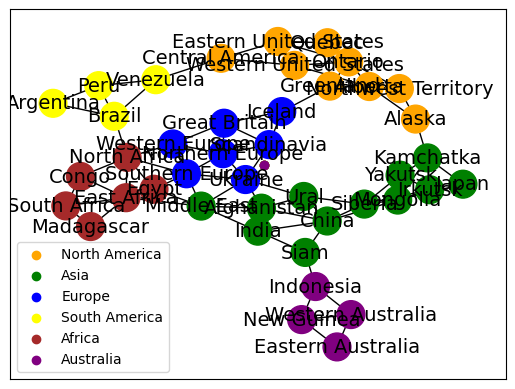

In [8]:
def visualize_risk_graph(G):
    """
    Create a visualization of the Risk board graph with continents colored differently.
    
    Parameters:
        G (nx.Graph): NetworkX graph of the Risk board
    """
    # Your code here
    layouts = ['circular_layout', 'planar_layout', 'random_layout', 'shell_layout',\
               'spring_layout', 'spectral_layout', 'spiral_layout', 'kamada_kawai_layout']
    # The above is a list containing different layouts which can be applied to nx.draw_networkx().
    # These string values themselves aren't used in the function itself, but they influence the output
    # of the graph via an if-else statement in the while-loop below. If the user types out one of the string
    # values in the list above, the nx method will be used when drawing the graph.

    colors = [] # Empty list which will contain a color name as a string in the index for each node
    continents = [] # Empty list which will contain a continent name as a string in the index for each node
    f = plt.figure(1) # Creates a figure in matplotlib. See source [1]
    ax = f.add_subplot(1,1,1) # Adds a subplot to the matplotlib figure declared above. See [1]
    
    for node in G.nodes(data='category'): # Loops through each node in G. See [2]
            
        if node[1] == "North America":    # For each continent that a node is in, append a continent and
            if node[1] not in continents: # color to the lists mentioned above. See [2]
                continents.append(node[1])
                ax.scatter([0],[0],color='orange',marker='o',label=node[1]) # Plots an invisible line used for 
            colors.append('orange')                                         # the legend. See [1]
        elif node[1] == "South America":
            if node[1] not in continents:
                continents.append(node[1])
                ax.scatter([0],[0],color='yellow',marker='o',label=node[1])
            colors.append('yellow')
        elif node[1] == "Europe":
            if node[1] not in continents:
                continents.append(node[1])
                ax.scatter([0],[0],color='blue',marker='o',label=node[1])
            colors.append('blue')
        elif node[1] == "Africa":
            if node[1] not in continents:
                continents.append(node[1])
                ax.scatter([0],[0],color='brown',marker='o',label=node[1])
            colors.append('brown')
        elif node[1] == "Asia":
            if node[1] not in continents:
                continents.append(node[1])
                ax.scatter([0],[0],color='green',marker='o',label=node[1])
            colors.append('green')
        elif node[1] == "Australia":
            if node[1] not in continents:
                continents.append(node[1])
                ax.scatter([0],[0],color='purple',marker='o',label=node[1])
            colors.append('purple')
        else:
            colors.append('black') # If a node doesn't have one of the above continents, set it to
                                   # the color black. This is a way to debug; None of the nodes should
                                   # be black after output if the continents were stored properly in G.
    
    while True:
        layout = input("What layout would you like?\nType 'options' if you'd like to see different layouts.\nIf you don't want to apply a layout, type 'none'.\n")
        # I wasn't sure what the third requirement wanted me to do without including the input function.
        # I know we haven't used that function yet in this course, or in CMSE 201, but I learned how to use
        # it during my time taking CSE 231 in a previous semester. If a reference is necessary, GeeksForGeeks
        # helped me refresh my memory about the function. Check out the article I listed as source [3].
        
        if layout == "options": # If the user types 'options', print the layouts list:
            print("List of options: ")
            print(layouts)

        elif layout == layouts[0]: # If the user chooses circular layout, draw with circular layout:
            nx.draw_networkx(G, pos=nx.circular_layout(G), node_color=colors, node_size=400, font_size=14, ax=ax)
            plt.legend()
            break

        elif layout == layouts[1]: # If the user chooses planar layout, draw with planar layout:
            nx.draw_networkx(G, pos=nx.planar_layout(G), node_color=colors, node_size=400, font_size=14, ax=ax)
            plt.legend()
            break

        elif layout == layouts[2]: # If the user chooses random layout, draw with random layout:
            nx.draw_networkx(G, pos=nx.random_layout(G), node_color=colors, node_size=400, font_size=14, ax=ax)
            plt.legend()
            break

        elif layout == layouts[3]: # If the user chooses shell layout, draw with shell layout:
            nx.draw_networkx(G, pos=nx.shell_layout(G), node_color=colors, node_size=400, font_size=14, ax=ax)
            plt.legend()
            break

        elif layout == layouts[4]: # If the user chooses spring layout, draw with spring layout:
            nx.draw_networkx(G, pos=nx.spring_layout(G), node_color=colors, node_size=400, font_size=14, ax=ax)
            plt.legend()
            break

        elif layout == layouts[5]: # If the user chooses spectral layout, draw with spectral layout:
            nx.draw_networkx(G, pos=nx.spectral_layout(G), node_color=colors, node_size=400, font_size=14, ax=ax)
            plt.legend()
            break

        elif layout == layouts[6]: # If the user chooses spiral layout, draw with spiral layout:
            nx.draw_networkx(G, pos=nx.spiral_layout(G), node_color=colors, node_size=400, font_size=14, ax=ax)
            plt.legend()
            break

        elif layout == layouts[7]: # If the user chooses Kamada-Kawai layout, draw with Kamada-Kawai layout:
            nx.draw_networkx(G, pos=nx.kamada_kawai_layout(G), node_color=colors, node_size=400, font_size=14, ax=ax)
            plt.legend()
            break
        
        else: # If the user types or enters anything else, don't include a specified layout:
            nx.draw_networkx(G, node_color=colors, node_size=400, font_size=14, ax=ax)
            plt.legend()
            break

# Visualize the graph
visualize_risk_graph(G)


&#9989; **Question 3.4 (26 points)**: Answer the following questions based on the Risk board graph visualization. Each answer should have a minimum of 1-2 sentences and snippet of the code that supports your answer. You must explain what each function in the code snippet does. 

All answers should be in the same markdown cell. 

The code snippet should be properly displayed using code markdown. 

1. Which layout type provides the best visualization of the continent-based clustering in the Risk board graph?
    - Explain the rationale behind your choice of layout.
2. Do a little research and explain what the Kamada-Kawai layout does? Make sure to cite your sources.
3. Which part of the code is used to assign the color of each node based on its continent?
4. How did you make the legend? Explain any non-obvious part of the code.
5. What colormap did you choose for the continents and how did you import the colormap? 
6. How did you set the node size and font size in the visualization?
7. How did you print the labels for the nodes? 

✎ 

 ***** **Note: I used [4,6] as references to type this markdown cell.** *****

<p><strong>1.</strong> I believe that the Kamada Kawai layout provides the best visualization of the Risk board graph. I explain more on how the Kamada Kawai layout works in number two, but basically, the algorithm that's used to produce the layout works well since it both prioritizes the shortest edges possible and avoids crossing any edges. This makes for a clean visual, as each edge can clearly be followed to the next node, and all of the nodes which are in the same continent are naturally close to each other.</p>

<p><strong>2.</strong> The Kamada-Kawai layout in NetworkX refers to the Kamada-Kawai algorithm, coined by Tomihisa Kamada and Satoru Kawai in July of 1988 [5]. It uses the physical properties of a spring as inspiration for the optimal layout of a graph. Basically, what that means is that each edge connecting a node is though of as a spring, and the layout of nodes and edges in which the total spring energy of the system is minimal would be considered the optimal layout. </p>

<p><strong>3.</strong> The part of my code that assigns the color of each node based on its continent is apart of a for-loop which starts at line 21 and ends on line 54. The part of the for-loop which pertains to the color assigning is the following:</p>
    
    ```
    colors = [] # Empty list which will contain a color name as a string in the index for each node
    
    for node in G.nodes(data='category'): # Loops through each node in G. See [2]
            
        if node[1] == "North America":
            colors.append('orange')                                      
        elif node[1] == "South America":
            colors.append('yellow')
        elif node[1] == "Europe":
            colors.append('blue')
        elif node[1] == "Africa":
            colors.append('brown')
        elif node[1] == "Asia":
            colors.append('green')
        elif node[1] == "Australia":
            colors.append('purple')
        else:
            colors.append('black') # If a node doesn't have one of the above continents, set it to
                                   # the color black. This is a way to debug; None of the nodes should
                                   # be black after output if the continents were stored properly in G.
    ```
<p>For each node, there is a category variable assigned to it which holds a string value indicating a continent. You're able to access it by calling the <code>[1]</code> index of a node. Since there are a predetermined amount of continents that I know the names of, I was able to write an if-else statement for each continent. If the continent that the node belongs to is a continent caught by the if-else statements, append a specific color to the <code>colors</code> list as a string. The reason as to why we are appending strings to the <code>colors</code> list is because of how <code>nx.draw_networkx</code> works; You can provide a list of colors to the <code>node_color</code> argument, and this will tell the function through each node and assign a color to it based on a node and a color's shared index. So, if you append a color to the same index as a node which corresponds to it's continent, you can then utilize <code>node_color</code> to color each node based on their continent. The reason as to why string values for colors work in this context is because NetworkX uses matplotlib.pyplot to draw graphs, and matplotlib.pyplot can take a color argument as a string.</p>

<p><strong>4.</strong> Creating a legend for this graph was not very straight-forwards. There is no command or parameter which can easily create a legend, so you have to plot invisible points pertaining to a continent's name and color, and call on them using <code>plt.legend()</code>. The code pertaining to the creation of the legend was apart of the same for-loop I mentioned above in number three. So, for clarity's sake, I removed the code which applied to color assignment, and only included code which involved the creation of the legend. Observe the following:</p>

    ```
    continents = [] # Empty list which will contain a continent name as a string in the index for each node
    f = plt.figure(1) # Creates a figure in matplotlib. See source [1]
    ax = f.add_subplot(1,1,1) # Adds a subplot to the matplotlib figure declared above. See [1]
    
    for node in G.nodes(data='category'): # Loops through each node in G. See [2]
            
        if node[1] == "North America":
            if node[1] not in continents:
                continents.append(node[1])
                ax.scatter([0],[0],color='orange',marker='o',label=node[1]) # Plots an invisible line 
                                                                            # used for the legend.
                                                                            # See [1]
        elif node[1] == "South America":
            if node[1] not in continents:
                continents.append(node[1])
                ax.scatter([0],[0],color='yellow',marker='o',label=node[1])
        elif node[1] == "Europe":
            if node[1] not in continents:
                continents.append(node[1])
                ax.scatter([0],[0],color='blue',marker='o',label=node[1])
        elif node[1] == "Africa":
            if node[1] not in continents:
                continents.append(node[1])
                ax.scatter([0],[0],color='brown',marker='o',label=node[1])
        elif node[1] == "Asia":
            if node[1] not in continents:
                continents.append(node[1])
                ax.scatter([0],[0],color='green',marker='o',label=node[1])
        elif node[1] == "Australia":
            if node[1] not in continents:
                continents.append(node[1])
                ax.scatter([0],[0],color='purple',marker='o',label=node[1])
    ```
<p>To create the legend, you first need to create a figure and a subplot single subplot using matplotlib.pyplot. I assigned the figure to variable <code>f</code>, and the subplot to the variable <code>ax</code>. Similarly to the assignment of colors, the creation of the legend relied upon the data acquired from the category of each node. Unlike the color assignment, though, we don't want to perform an operation for each node. We only want to plot one invisible point per continent. Otherwise, the legend will have points for every node So, what I did was create the list called <code>continents</code>. The purpose of this list is to track each unique continent. This is useful, because we can then use an if-statement in the if-else statements pertaining to each continent to check if we've encountered that continent yet. If we haven't the list won't contain the string value for it, so we can then plot an invisible point correlating to the continent and append the continent as a string to <code>continents</code>. Once the loop is over, and we have a unique point plotted for each continent with the correct color associated with it, you can then call <code>plt.legend()</code> after drawing the graph to get a legend. Note: I did not come up with this method on my own. I had a lot of help from the stack overflow post listed as source [1].</p>
    
<p><strong>5.</strong> I understand that matplotlib.pyplot is able to take a specific color map, like "virdis", as an input during the graphing process. I chose not to use this feature, and assigned colors using the method described in number three above. Though, I can explain why I chose the colors I did. All I did was go off of the image of the Risk board given to me at the top of this notebook; For example, North America is colored orange, so I made all of the nodes in North America the color orange. </p>

<p><strong>6.</strong> To change the node size and font size in a graph visualization, you can use the <code>node_size</code> and <code>font_size</code> arguments in the <code>nx.draw_networkx</code> function. Take the following piece of code as an example: </p>

    ```
    nx.draw_networkx(G, pos=nx.kamada_kawai_layout(G), node_color=colors, node_size=400, font_size=14, ax=ax)
    ```
    
<p>The default node size is 300. Since I wanted to increase the size of my nodes, I made the <code>node_size</code> argument equal to 400. It's a similar story for font size: The default font size is 12 for nodes. Since I wanted a larger font size, I set <code>font_size</code> equal to 14.</p>
<p><strong>7.</strong> The labels are on by default when using <code>nx.draw_networkx</code>, but if you want to make sure they stay on, there is a function called <code>nx.draw_networkx_labels</code> which you can use. It takes a NetworkX graph and a list of positions as required parameters, and the rest are optional parameters which control things like font color, font weight, font transparency, and whatnot. Here's an example snippet of code which utilizes the <code>nx.draw_networkx_labels</code> function:</p>

    ```
    Kfour = np.matrix([[0,1,1,1],[1,0,1,1],[1,1,0,1],[1,1,1,0]])
    k4 = nx.Graph(Kfour)
    
    positions = {0:(-2,2), 1:(2,2), 2:(0,-2), 3:(0,0)}
    nx.draw(k4, pos=positions)
    nx.draw_networkx_labels(k4, pos=positions, font_size=14, font_family="monospace") # The available 
                                                                                      # font-families
                                                                                      # are the same
                                                                                      # as the ones
                                                                                      # in 
                                                                                      # matplotlib.
                                                                                      # See source 
                                                                                      # [7].
    ```

## My Sources:

[1] Dupond, "legend in python networkx," Stack Overflow, April 2014. Available: Stack Overflow, https://stackoverflow.com/questions/22992009/legend-in-python-networkx [Accessed Mar. 23, 2025].

[2] A. Hagburg, D. Schult and P. Swiert, "Graph.nodes," Software for Complex Networks, October 2024. Available: NetworkX, https://networkx.org/documentation/stable/reference/classes/generated/networkx.Graph.nodes.html#networkx.Graph.nodes

[3] "Taking input in Python," GeeksForGeeks, January 2025. Available: GeeksForGeeks, https://www.geeksforgeeks.org/taking-input-in-python/

[4] "Markdown Tutorial," CommonMark. Available: CommonMark, https://commonmark.org/help/tutorial/09-code.html

[5] T. Kamada and S. Kawai, "An algorithm for drawing general undirected graphs,
Information Processing Letters, Volume 31, Issue 1, 1989, Pages 7-15, ISSN 0020-0190, https://doi.org/10.1016/0020-0190(89)90102-6. (https://www.sciencedirect.com/science/article/pii/0020019089901026)

[6] M. Cone, "Basic Syntax," Markdown Guide, 2025. Available: Markdown Guide, https://www.markdownguide.org/basic-syntax

[7] J. D. Hunter, "Matplotlib: A 2D Graphics Environment", Computing in Science & Engineering, vol. 9, no. 3, pp. 90-95, 2007. Available: Matplotlib, https://matplotlib.org/stable/gallery/text_labels_and_annotations/font_family_rc.html

---
## &#128721; STOP
**Pause to commit your changes to your Git repository! (1 points)**

Take a moment to save your notebook, commit the changes to your Git repository using the commit message "**Committing Part 3**", no need to push the changes to GitHub yet, but you can if you want.

---
## Assignment wrap-up

Please fill out the form that appears when you run the code below.  **You must completely fill this out in order to receive credit for the assignment!**

In [ ]:
from IPython.display import HTML
HTML(
"""
<iframe 
	src="https://forms.office.com/r/mB0YjLYvAA" 
	width="800px" 
	height="600px" 
	frameborder="0" 
	marginheight="0" 
	marginwidth="0">
	Loading...
</iframe>
"""
)

### Congratulations, you're done!

If you like, you can upload this file to D2L for a record. Nevertheless, **we will grade the copy on GitHub**. 


&#169; Copyright 2025,  Department of Computational Mathematics, Science and Engineering at Michigan State University